In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance
from lightgbm import LGBMRegressor
import os
import fiona
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

<ipython-input-3-5947731c6bde>:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid


In [4]:
print(caserne.crs)
print(compagnies.crs)

epsg:2154
epsg:2154


In [5]:
caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y

In [6]:
compagnies = compagnies.to_crs(epsg=4326)
print(compagnies.geometry.head())

0    POLYGON ((5.98589 47.33082, 5.98621 47.33091, ...
1    POLYGON ((6.37208 47.28665, 6.37036 47.28572, ...
2    POLYGON ((6.17776 47.01394, 6.17858 47.01315, ...
3    POLYGON ((6.29216 46.85959, 6.29174 46.85793, ...
4    MULTIPOLYGON (((6.35375 46.71830, 6.35262 46.7...
Name: geometry, dtype: geometry


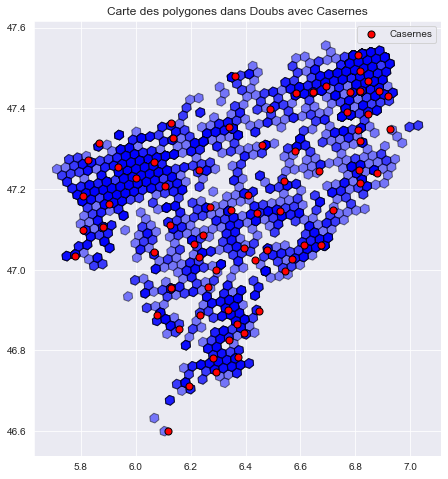

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
doubs_data.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

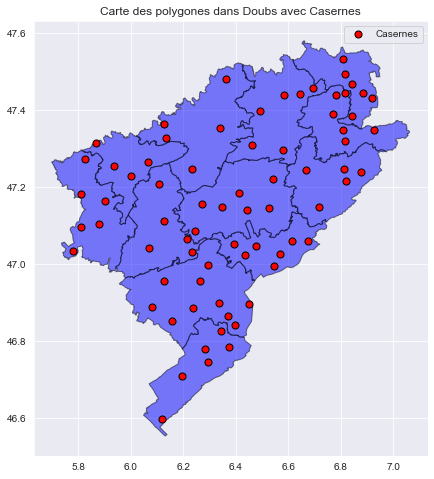

In [8]:
fig, ax = plt.subplots(figsize=(8,8))
compagnies.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

In [9]:
def get_nearest_caserne_distance(hexagon, caserne):
    distances = caserne.geometry.distance(hexagon)
    return distances.min()

doubs_data['distance_to_nearest_caserne'] = doubs_data.geometry.apply(get_nearest_caserne_distance, caserne=caserne)
print(doubs_data[['geometry', 'distance_to_nearest_caserne']].head())

<ipython-input-9-6511cbd39df2>:2: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = caserne.geometry.distance(hexagon)


                                            geometry  \
0  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...   
1  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
2  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
3  POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...   
4  POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...   

   distance_to_nearest_caserne  
0                     0.000000  
1                     0.005327  
2                     0.005327  
3                     0.039716  
4                     0.010387  


In [10]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

print(doubs_data.head())

            hex_id raison_sortie          date_debut            date_fin  \
0  871f820aaffffff      NATURELS 2014-10-02 14:08:53 2014-10-02 19:54:25   
1  871f82d61ffffff      NATURELS 2014-10-03 19:33:59 2014-10-03 19:55:31   
2  871f82d61ffffff      NATURELS 2014-10-04 19:24:49 2014-10-04 19:59:02   
3  871f82d4dffffff      NATURELS 2014-10-04 20:10:43 2014-10-04 20:42:34   
4  871f82700ffffff      NATURELS 2014-10-05 12:57:52 2014-10-05 13:24:24   

   label    year       date           departement  duree_minutes  \
0    1.0  2014.0 2014-10-02  departement-25-doubs     345.533333   
1    1.0  2014.0 2014-10-03  departement-25-doubs      21.533333   
2    1.0  2014.0 2014-10-04  departement-25-doubs      34.216667   
3    1.0  2014.0 2014-10-04  departement-25-doubs      31.850000   
4    1.0  2014.0 2014-10-05  departement-25-doubs      26.533333   

                                            geometry  ... water       tree  \
0  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...  ..

In [11]:
doubs_data = doubs_data.drop(columns=['date', 'departement', 'geometry', 'duree', 'centroid', 'scale0', 'sinister', 'date_debut', 'date_fin', 'raison_sortie', 'label', 'year'], errors='ignore')

In [12]:
# Calcul des statistiques pour chaque `hex_id`
doubs_moy = doubs_data.groupby('hex_id').agg(
    {'duree_minutes': ['mean', 'max', 'min', 'std'],
     'centroid_lon': 'mean',
     'centroid_lat': 'mean',
     'distance_to_nearest_caserne': 'mean',
     'NDVI': 'mean',
     'NDMI': 'mean',
     'NDBI': 'mean',
     'NDSI': 'mean',
     'NDWI': 'mean',
     'osmnx': 'mean',
     'PasDeRoute': 'mean',
     'motorway': 'mean',
     'primary': 'mean',
     'secondary': 'mean',
     'tertiary': 'mean',
     'path': 'mean',
     'population': 'mean',
     'elevation': 'mean',
     'foret_encoder': 'mean',
     'highway_encoder': 'mean',
     'foret': 'mean',
     'PasDeforet': 'mean',
     'Châtaignier': 'mean',
     'Chênes décidus': 'mean',
     'Conifères': 'mean',
     'Douglas': 'mean',
     'Feuillus': 'mean',
     'Hêtre': 'mean',
     'Mixte': 'mean',
     'Mélèze': 'mean',
     'NC': 'mean',
     'NR': 'mean',
     'Peuplier': 'mean',
     'Pin autre': 'mean',
     'Pin laricio, pin noir': 'mean',
     'Pin maritime': 'mean',
     'Pin sylvestre': 'mean',
     'Pins mélangés': 'mean',
     'Robinier': 'mean',
     'Sapin, épicéa': 'mean',
     'dynamic_world': 'mean',
     'water': 'mean',
     'tree': 'mean',
     'grass': 'mean',
     'crops': 'mean',
     'shrub': 'mean',
     'flooded': 'mean',
     'built': 'mean',
     'bare': 'mean',
     'snow': 'mean'}
).reset_index()

doubs_moy.columns = ['_'.join(col).strip() for col in doubs_moy.columns.values]
doubs_moy.head()

,hex_id_,duree_minutes_mean,duree_minutes_max,duree_minutes_min,duree_minutes_std,centroid_lon_mean,centroid_lat_mean,distance_to_nearest_caserne_mean,NDVI_mean,NDMI_mean,...,dynamic_world_mean,water_mean,tree_mean,grass_mean,crops_mean,shrub_mean,flooded_mean,built_mean,bare_mean,snow_mean
0,871f80492ffffff,117.325000,197.783333,40.850000,66.540232,6.350198,47.477082,0.000000,0.720443,0.145452,...,NaN,0.012568,35.314817,25.637803,0.062838,4.700264,0.000000,1.156215,0.0,0.0
1,871f80493ffffff,79.483333,126.966667,32.000000,67.151574,6.381746,47.480996,0.003200,0.739361,0.162564,...,NaN,0.000000,49.805252,11.056665,0.175901,4.611132,0.037693,3.982912,0.0,0.0
2,871f80498ffffff,160.133333,160.133333,160.133333,NaN,6.444873,47.488800,0.066766,0.785204,0.193932,...,NaN,0.000000,86.613086,4.633932,0.012558,0.000000,0.000000,0.000000,0.0,0.0
3,871f8049affffff,65.383333,65.383333,65.383333,NaN,6.431903,47.468880,0.053004,0.778036,0.189057,...,NaN,0.000000,48.172799,15.509230,0.226045,0.653020,0.012558,2.687429,0.0,0.0
4,871f8049cffffff,89.400000,89.400000,89.400000,NaN,6.426270,47.504821,0.051726,0.751272,0.175163,...,NaN,0.050245,40.723527,26.692627,0.037684,0.565256,0.012561,3.052380,0.0,0.0


Dimensions du DataFrame :
(699, 54)

Info sur les types de données et les valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   hex_id_                           699 non-null    object 
 1   duree_minutes_mean                699 non-null    float64
 2   duree_minutes_max                 699 non-null    float64
 3   duree_minutes_min                 699 non-null    float64
 4   duree_minutes_std                 453 non-null    float64
 5   centroid_lon_mean                 699 non-null    float64
 6   centroid_lat_mean                 699 non-null    float64
 7   distance_to_nearest_caserne_mean  699 non-null    float64
 8   NDVI_mean                         627 non-null    float64
 9   NDMI_mean                         627 non-null    float64
 10  NDBI_mean                         627 n

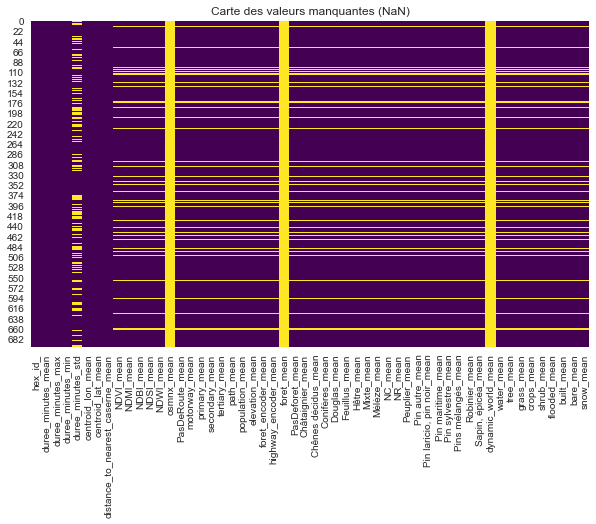


Nombre de valeurs manquantes (NaN) par colonne :
hex_id_                               0
duree_minutes_mean                    0
duree_minutes_max                     0
duree_minutes_min                     0
duree_minutes_std                   246
centroid_lon_mean                     0
centroid_lat_mean                     0
distance_to_nearest_caserne_mean      0
NDVI_mean                            72
NDMI_mean                            72
NDBI_mean                            72
NDSI_mean                            72
NDWI_mean                            72
osmnx_mean                          699
PasDeRoute_mean                      72
motorway_mean                        72
primary_mean                         72
secondary_mean                       72
tertiary_mean                        72
path_mean                            72
population_mean                      72
elevation_mean                       72
foret_encoder_mean                   72
highway_encoder_mean          

In [13]:
print("Dimensions du DataFrame :")
print(doubs_moy.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(doubs_moy.info())

plt.figure(figsize=(10, 6))
sns.heatmap(doubs_moy.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(doubs_moy.isnull().sum())

In [14]:
nan_percentage = doubs_moy.isnull().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 80].index

doubs_moy = doubs_moy[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(doubs_moy.shape)

print("\nColonnes restantes après nettoyage :")
print(doubs_moy.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(699, 51)

Colonnes restantes après nettoyage :
Index(['hex_id_', 'duree_minutes_mean', 'duree_minutes_max',
       'duree_minutes_min', 'duree_minutes_std', 'centroid_lon_mean',
       'centroid_lat_mean', 'distance_to_nearest_caserne_mean', 'NDVI_mean',
       'NDMI_mean', 'NDBI_mean', 'NDSI_mean', 'NDWI_mean', 'PasDeRoute_mean',
       'motorway_mean', 'primary_mean', 'secondary_mean', 'tertiary_mean',
       'path_mean', 'population_mean', 'elevation_mean', 'foret_encoder_mean',
       'highway_encoder_mean', 'PasDeforet_mean', 'Châtaignier_mean',
       'Chênes décidus_mean', 'Conifères_mean', 'Douglas_mean',
       'Feuillus_mean', 'Hêtre_mean', 'Mixte_mean', 'Mélèze_mean', 'NC_mean',
       'NR_mean', 'Peuplier_mean', 'Pin autre_mean',
       'Pin laricio, pin noir_mean', 'Pin maritime_mean', 'Pin sylvestre_mean',
       'Pins mélangés_mean', 'Robinier_mean', 'Sapin, épicéa_mean',
       'water_mea

In [15]:
doubs_moy = doubs_moy.dropna()

print("\nVérification des NaN après suppression des lignes dans doubs_moy :")
print(doubs_moy.isnull().sum())

print("\nDimensions du DataFrame doubs_moy après suppression des NaN :")
print(doubs_moy.shape)


Vérification des NaN après suppression des lignes dans doubs_moy :
hex_id_                             0
duree_minutes_mean                  0
duree_minutes_max                   0
duree_minutes_min                   0
duree_minutes_std                   0
centroid_lon_mean                   0
centroid_lat_mean                   0
distance_to_nearest_caserne_mean    0
NDVI_mean                           0
NDMI_mean                           0
NDBI_mean                           0
NDSI_mean                           0
NDWI_mean                           0
PasDeRoute_mean                     0
motorway_mean                       0
primary_mean                        0
secondary_mean                      0
tertiary_mean                       0
path_mean                           0
population_mean                     0
elevation_mean                      0
foret_encoder_mean                  0
highway_encoder_mean                0
PasDeforet_mean                     0
Châtaignier_mean    

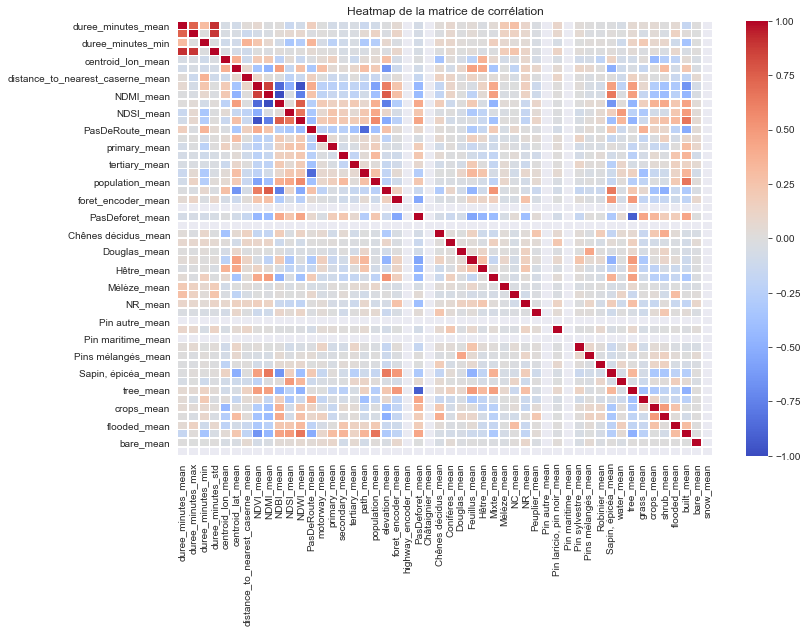

In [16]:
corr_matrix = doubs_moy.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.6)
plt.title("Heatmap de la matrice de corrélation")
plt.show()

In [17]:
correlation_threshold = 0.9

correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[i]
            correlated_features.add(colname)

print("Features trop corrélées à supprimer :", correlated_features)

Features trop corrélées à supprimer : {'duree_minutes_std', 'tree_mean', 'NDBI_mean', 'NDWI_mean'}


In [18]:
doubs_moy_cleaned = doubs_moy.drop(columns=correlated_features)

print("Dataset après suppression des features trop corrélées :", doubs_moy_cleaned.shape)

Dataset après suppression des features trop corrélées : (408, 47)


In [19]:
X = doubs_moy_cleaned.drop(columns=["duree_minutes_mean", 'hex_id_'])
y = doubs_moy_cleaned["duree_minutes_mean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Taille du dataset d'entraînement :", X_train.shape)
print("Taille du dataset de test :", X_test.shape)


Taille du dataset d'entraînement : (326, 45)
Taille du dataset de test : (82, 45)


In [20]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")

MAE : 13.209
RMSE : 29.456


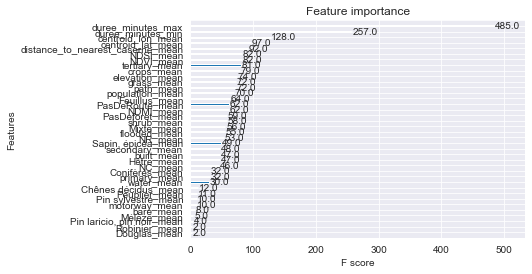

In [22]:
plot_importance(xgb_model)
plt.show()

In [23]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

              Feature  Importance
0   duree_minutes_max    0.329563
27            NC_mean    0.285688
3   centroid_lat_mean    0.182707
2   centroid_lon_mean    0.054543
1   duree_minutes_min    0.048445
11     secondary_mean    0.024772
41       flooded_mean    0.013468
7           NDSI_mean    0.010958
42         built_mean    0.008419
23      Feuillus_mean    0.006269


In [24]:
top_n = 10
top_features = feature_importance_df.head(top_n)["Feature"].values

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

In [25]:
xgb_model_selected = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_model_selected.fit(X_train_selected, y_train)

y_pred_selected = xgb_model_selected.predict(X_test_selected)

In [26]:
mae_selected = mean_absolute_error(y_test, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))

print(f"MAE avec features sélectionnées : {mae_selected:.3f}")
print(f"RMSE avec features sélectionnées : {rmse_selected:.3f}")

MAE avec features sélectionnées : 13.364
RMSE avec features sélectionnées : 36.394


In [28]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = doubs_moy_cleaned.drop(columns=["duree_minutes_mean", 'hex_id_'])  # Features
y = doubs_moy_cleaned["duree_minutes_mean"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

objectives = ["reg:squarederror", "reg:absoluteerror", "reg:pseudohubererror"]

results = {}

for obj in objectives:
    print(f" Test de la fonction objectif : {obj}")

    model = XGBRegressor(objective=obj, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[obj] = {"MAE": mae, "RMSE": rmse}

    print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}\n")

for obj, metrics in results.items():
    print(f" {obj} -> MAE: {metrics['MAE']:.3f}, RMSE: {metrics['RMSE']:.3f}")

🔍 Test de la fonction objectif : reg:squarederror
MAE: 13.209, RMSE: 29.456

🔍 Test de la fonction objectif : reg:absoluteerror
MAE: 19.745, RMSE: 52.411

🔍 Test de la fonction objectif : reg:pseudohubererror
MAE: 308105.860, RMSE: 308105.868

📊 reg:squarederror -> MAE: 13.209, RMSE: 29.456
📊 reg:absoluteerror -> MAE: 19.745, RMSE: 52.411
📊 reg:pseudohubererror -> MAE: 308105.860, RMSE: 308105.868


In [29]:
import numpy as np
import xgboost as xgb

def custom_loss(y_true, y_pred, alpha=0.5):
    error = y_pred - y_true

    grad = alpha * 2 * error + (1 - alpha) * np.sign(error)

    hess = alpha * 2 * np.ones_like(error)

    return grad, hess

model = xgb.XGBRegressor(objective=custom_loss, random_state=42)

🔍 Test de alpha = 0.1
MAE: 12.995, RMSE: 19.278

🔍 Test de alpha = 0.2
MAE: 12.202, RMSE: 19.285

🔍 Test de alpha = 0.3
MAE: 11.874, RMSE: 22.444

🔍 Test de alpha = 0.4
MAE: 10.228, RMSE: 18.333

🔍 Test de alpha = 0.5
MAE: 13.619, RMSE: 44.707

🔍 Test de alpha = 0.6
MAE: 12.432, RMSE: 36.122

🔍 Test de alpha = 0.7
MAE: 11.677, RMSE: 31.076

🔍 Test de alpha = 0.8
MAE: 15.291, RMSE: 59.678

🔍 Test de alpha = 0.9
MAE: 15.082, RMSE: 56.611



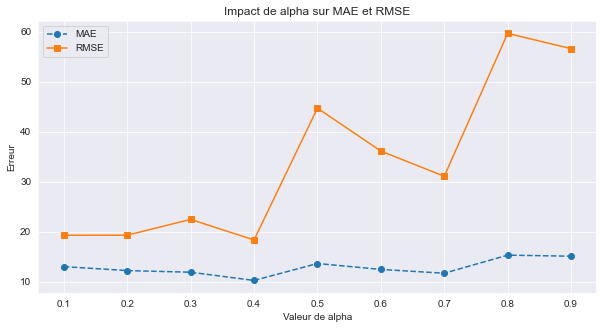

In [34]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def custom_loss(alpha):
    def loss(y_true, y_pred):
        error = y_pred - y_true
        grad = alpha * 2 * error + (1 - alpha) * np.sign(error)
        hess = alpha * 2 * np.ones_like(error)
        return grad, hess
    return loss

X = doubs_moy_cleaned.drop(columns=["duree_minutes_mean", 'hex_id_'])  # Features
y = doubs_moy_cleaned["duree_minutes_mean"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = {}

for alpha in alpha_values:
    print(f"🔍 Test de alpha = {alpha}")

    model = xgb.XGBRegressor(objective=custom_loss(alpha), random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[alpha] = {"MAE": mae, "RMSE": rmse}
    print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}\n")

alphas = list(results.keys())
maes = [results[a]["MAE"] for a in alphas]
rmses = [results[a]["RMSE"] for a in alphas]

plt.figure(figsize=(10,5))
plt.plot(alphas, maes, marker='o', label="MAE", linestyle="--")
plt.plot(alphas, rmses, marker='s', label="RMSE", linestyle="-")
plt.xlabel("Valeur de alpha")
plt.ylabel("Erreur")
plt.legend()
plt.title("Impact de alpha sur MAE et RMSE")
plt.show()

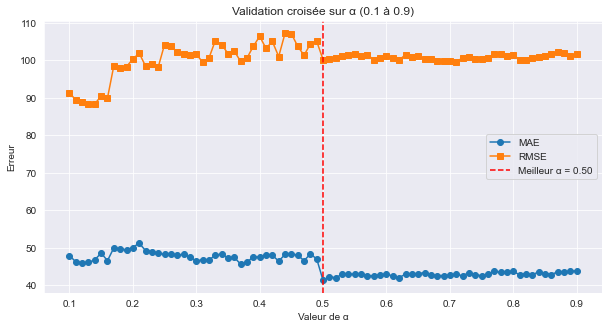

✅ Meilleur alpha : 0.50 avec MAE = 41.327 et RMSE = 100.209


In [62]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

X = doubs_moy_cleaned.drop(columns=["duree_minutes_mean", 'hex_id_', 'duree_minutes_max', 'duree_minutes_min'])
y = doubs_moy_cleaned["duree_minutes_mean"]  # Target

cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

alphas = np.arange(0.1, 0.91, 0.01)

results = []

for alpha in alphas:
    def custom_loss(y_true, y_pred):
        error = y_pred - y_true
        grad = alpha * 2 * error + (1 - alpha) * np.sign(error)
        hess = alpha * 2 * np.ones_like(error)
        return grad, hess

    model = xgb.XGBRegressor(objective=custom_loss, random_state=42)

    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring=mae_scorer)
    rmse_scores = -cross_val_score(model, X, y, cv=cv, scoring=rmse_scorer)

    results.append((alpha, mae_scores.mean(), rmse_scores.mean()))

results = np.array(results)

best_alpha_idx = np.argmin(results[:, 1])
best_alpha = results[best_alpha_idx, 0]
best_mae = results[best_alpha_idx, 1]
best_rmse = results[best_alpha_idx, 2]

plt.figure(figsize=(10, 5))
plt.plot(results[:, 0], results[:, 1], marker='o', label="MAE")
plt.plot(results[:, 0], results[:, 2], marker='s', label="RMSE")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"Meilleur α = {best_alpha:.2f}")
plt.xlabel("Valeur de α")
plt.ylabel("Erreur")
plt.legend()
plt.title("Validation croisée sur α (0.1 à 0.9)")
plt.show()

print(f"✅ Meilleur alpha : {best_alpha:.2f} avec MAE = {best_mae:.3f} et RMSE = {best_rmse:.3f}")

In [63]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid_learning_rate = {'learning_rate': [0.05, 0.1, 0.2]}
param_grid_max_depth = {'max_depth': [3, 4, 5]}
param_grid_colsample_bytree = {'colsample_bytree': [0.6, 0.7, 0.8]}
param_grid_subsample = {'subsample': [0.8, 0.9, 1.0]}
param_grid_n_estimators = {'n_estimators': [100, 200, 300]}
param_grid_gamma = {'gamma': [0, 0.1, 0.2]}
param_grid_min_child_weight = {'min_child_weight': [1, 3, 5]}
param_grid_scale_pos_weight = {'scale_pos_weight': [1, 2]}
param_grid_lambda = {'lambda': [0, 0.1, 0.2]}
param_grid_alpha = {'alpha': [0, 0.1, 0.2]}

def search_param(param_grid, X, y):
    xgb = XGBRegressor()
    grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=1)
    grid_search.fit(X, y)
    return grid_search.best_params_, -grid_search.best_score_

best_learning_rate, best_lr_mae = search_param(param_grid_learning_rate, X, y)
best_max_depth, best_md_mae = search_param(param_grid_max_depth, X, y)
best_colsample_bytree, best_cb_mae = search_param(param_grid_colsample_bytree, X, y)
best_subsample, best_ss_mae = search_param(param_grid_subsample, X, y)
best_n_estimators, best_ne_mae = search_param(param_grid_n_estimators, X, y)
best_gamma, best_gamma_mae = search_param(param_grid_gamma, X, y)
best_min_child_weight, best_mc_mae = search_param(param_grid_min_child_weight, X, y)
best_scale_pos_weight, best_spw_mae = search_param(param_grid_scale_pos_weight, X, y)
best_lambda, best_lambda_mae = search_param(param_grid_lambda, X, y)
best_alpha, best_alpha_mae = search_param(param_grid_alpha, X, y)

print("Meilleur learning_rate : ", best_learning_rate, "avec MAE : ", best_lr_mae)
print("Meilleur max_depth : ", best_max_depth, "avec MAE : ", best_md_mae)
print("Meilleur colsample_bytree : ", best_colsample_bytree, "avec MAE : ", best_cb_mae)
print("Meilleur subsample : ", best_subsample, "avec MAE : ", best_ss_mae)
print("Meilleur n_estimators : ", best_n_estimators, "avec MAE : ", best_ne_mae)
print("Meilleur gamma : ", best_gamma, "avec MAE : ", best_gamma_mae)
print("Meilleur min_child_weight : ", best_min_child_weight, "avec MAE : ", best_mc_mae)
print("Meilleur scale_pos_weight : ", best_scale_pos_weight, "avec MAE : ", best_spw_mae)
print("Meilleur lambda : ", best_lambda, "avec MAE : ", best_lambda_mae)
print("Meilleur alpha : ", best_alpha, "avec MAE : ", best_alpha_mae)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Meilleur learning_rate :  {'learning_rate': 0.05} avec MAE :  44.13658809485184
Meilleur max_depth :  {'max_depth': 3} avec MAE :  45.5727978508177
Meilleur colsample_bytree :  {'colsample_bytree': 0.6} avec MAE :  45.19384225490709
Meilleur subsample :  {'subsample': 0.9} avec MAE :  46.70797304690904
Meilleur n_estimators :  {'n_estimators': 100} avec MAE :  46.73655324904263
Meilleur gamma :  {'gamma': 0

In [64]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_model = XGBRegressor(
    learning_rate=0.05,
    max_depth=3,
    colsample_bytree=0.8,
    subsample=1.0,
    n_estimators=100,
    gamma=0,
    min_child_weight=3,
    scale_pos_weight=1,
    reg_lambda=0.1,
    alpha=0.2,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE sur test : {mae}")
print(f"RMSE sur test : {rmse}")


MAE sur test : 10.450367232320067
RMSE sur test : 16.59492257663602


In [65]:
y_train_pred = xgb_model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE sur l'entraînement : {train_mae}")
print(f"RMSE sur l'entraînement : {train_rmse}")
print(f"MAE sur le test : {test_mae}")
print(f"RMSE sur le test : {test_rmse}")

MAE sur l'entraînement : 10.802410522009888
RMSE sur l'entraînement : 28.82453812531022
MAE sur le test : 10.450367232320067
RMSE sur le test : 16.59492257663602


In [66]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f"Scores de la validation croisée : {scores}")
print(f"MAE moyen de la validation croisée : {-scores.mean()}")

Scores de la validation croisée : [-26.62819776 -23.29547737 -11.50098623 -14.48727589 -24.46182737]
MAE moyen de la validation croisée : 20.074752925427113


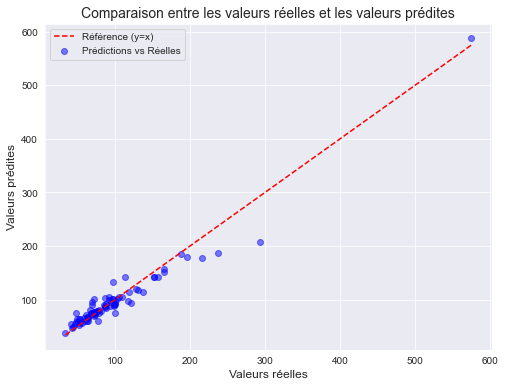

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Prédictions vs Réelles')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Référence (y=x)')

plt.title('Comparaison entre les valeurs réelles et les valeurs prédites', fontsize=14)
plt.xlabel('Valeurs réelles', fontsize=12)
plt.ylabel('Valeurs prédites', fontsize=12)
plt.legend()

plt.show()

In [68]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

params = {
    'learning_rate': 0.05,
    'max_depth': 3,
    'colsample_bytree': 0.8,
    'subsample': 1.0,
    'n_estimators': 100,
    'gamma': 0,
    'min_child_weight': 3,
    'scale_pos_weight': 1,
    'reg_lambda': 0.1,
    'alpha': 0.2,
    'eval_metric': 'mae',
    'objective': 'reg:squarederror'
}

evals = [(dtrain, 'train'), (dvalid, 'eval')]

num_round = 10000000
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_round,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=10
)

y_pred = bst.predict(dvalid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = mean_squared_error(y_valid, y_pred, squared=False)

print(f"MAE sur le jeu de validation : {mae}")
print(f"RMSE sur le jeu de validation : {rmse}")

[0]	train-mae:38.75719	eval-mae:39.85791
[10]	train-mae:36.83252	eval-mae:39.16555
[20]	train-mae:35.86200	eval-mae:38.19672
[30]	train-mae:34.55015	eval-mae:37.39632
[40]	train-mae:32.58921	eval-mae:37.68283
[50]	train-mae:30.56903	eval-mae:37.63659
[60]	train-mae:28.85484	eval-mae:37.52397
[70]	train-mae:27.83277	eval-mae:37.46506


/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [11:36:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[80]	train-mae:26.55274	eval-mae:38.18647
[90]	train-mae:25.57144	eval-mae:37.96980
[100]	train-mae:24.79801	eval-mae:38.26323
[110]	train-mae:23.96864	eval-mae:38.29871
[112]	train-mae:23.83030	eval-mae:38.40503
MAE sur le jeu de validation : 38.40682700747361
RMSE sur le jeu de validation : 72.9615065763139
